In [1]:
from sotodlib import core, io

import datetime as dt

import copy

import numpy as np
import dill as pk

from optical_loading import pwv_interp
import utils.map_utils as mu 
from utils.parsing import parse_dict, parse_neps
import astropy.units as u
from astropy.time import Time
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import h5py

pwv = pwv_interp()

    
with open("backups/nets_111925.pk", "rb") as f:
    net_dict = pk.load(f)


%load_ext autoreload
%autoreload 2

/so/home/jorlo/venvs/sotodlib/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = parse_dict(net_dict=net_dict)

<Axes: xlabel='neps', ylabel='labels'>

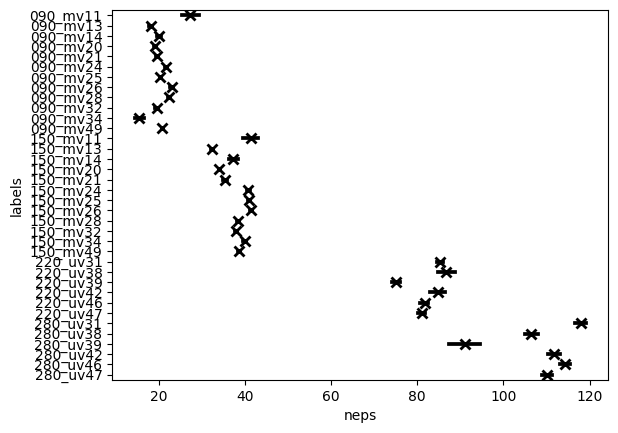

In [4]:
t_cut_low = Time("2025-03-05T00:00:00", format="isot", scale="utc")
t_cut_high = Time("2026-05-03T00:00:00", format="isot", scale="utc")
sns.pointplot(data=df.where((1.1 < df.pwv/np.sin(np.deg2rad(df.el))) & (df.pwv/np.sin(np.deg2rad(df.el)) < 1.5) & (df.t_obs < t_cut_high.unix ) & (t_cut_low.unix < df.t_obs)), x="neps", y="labels", linestyle="none", marker="x", color="black", zorder=2)


In [5]:
nep_df = parse_neps(net_dict=net_dict)

/so/home/jorlo/dev/LAT_analysis/utils/parsing.py:140: RuntimeWarning: invalid value encountered in scalar divide
  neis.append(nep/cur_phicals[j][i] * 9e6/(2 * np.pi))


In [6]:
neps = nep_df.neps.to_numpy()
nep_labels = nep_df.labels.to_numpy(dtype=str)

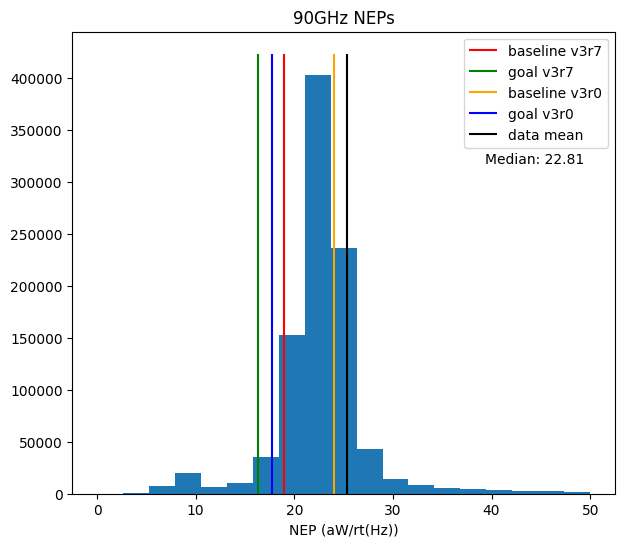

In [20]:
f, ax = plt.subplots(figsize=(7, 6))
flags = np.where((np.char.find(nep_labels, "090") != -1) & (neps>1e-6) & (1.1 < nep_df.pwv/np.sin(np.deg2rad(nep_df.el))) & (nep_df.pwv/np.sin(np.deg2rad(nep_df.el)) < 1.5))[0]

baseline_r0 = 24.04
baseline_r7 = 18.99

goal_r0 = 17.70
goal_r7 = 16.37

plt.hist(neps[flags]*1e6, bins = np.linspace(0,50, 20))
#plt.hist(neps_snork_090*1e6/baseline, bins = np.linspace(0,2, 20), label = "Snorkel Stare", density = True, alpha = 0.5)
ymax, ymin = ax.get_ylim()
xmax, xmin = ax.get_xlim()
plt.vlines(baseline_r7, ymin, ymax, label="baseline v3r7", color="red")
plt.vlines(goal_r7, ymin, ymax, label="goal v3r7", color="green")
plt.vlines(baseline_r0, ymin, ymax, label="baseline v3r0", color="orange")
plt.vlines(goal_r0, ymin, ymax, label="goal v3r0", color="blue")
plt.vlines(np.nanmean(neps[flags]*1e6), ymin, ymax, label="data mean", color="black")
plt.xlabel("NEP (aW/rt(Hz))")
plt.title("90GHz NEPs")
plt.legend()

plt.text(0.75*xmin, 0.75*ymin, "Median: {:.2f}".format(np.nanmedian(neps[flags]*1e6)))

f.savefig("./plts/neps/neps_090.pdf", dpi=600, bbox_inches='tight')
f.savefig("./plts/neps/neps_090.png", dpi=600, bbox_inches='tight')

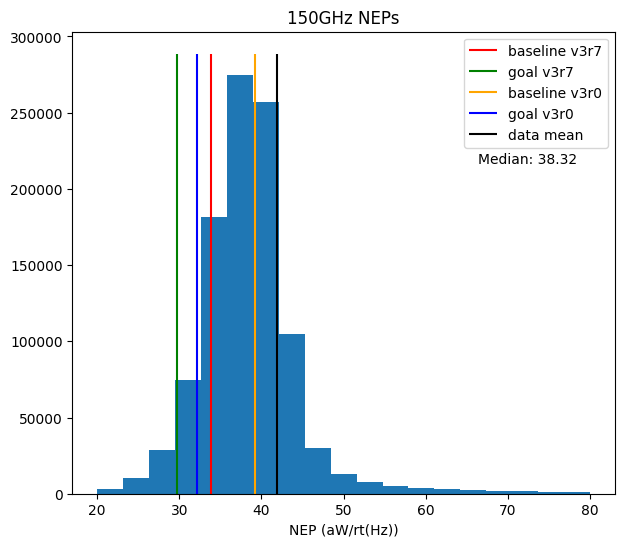

In [27]:
f, ax = plt.subplots(figsize=(7, 6))
flags = np.where((np.char.find(nep_labels, "150") != -1) & (neps>1e-6) & (1.1 < nep_df.pwv/np.sin(np.deg2rad(nep_df.el))) & (nep_df.pwv/np.sin(np.deg2rad(nep_df.el)) < 1.5))[0]

baseline_r0 = 39.25
baseline_r7 = 33.81

goal_r0 = 32.13
goal_r7 = 29.72

plt.hist(neps[flags]*1e6, bins = np.linspace(20,80, 20))
#plt.hist(neps_snork_090*1e6/baseline, bins = np.linspace(0,2, 20), label = "Snorkel Stare", density = True, alpha = 0.5)
ymax, ymin = ax.get_ylim()
xmax, xmin = ax.get_xlim()
plt.vlines(baseline_r7, ymin, ymax, label="baseline v3r7", color="red")
plt.vlines(goal_r7, ymin, ymax, label="goal v3r7", color="green")
plt.vlines(baseline_r0, ymin, ymax, label="baseline v3r0", color="orange")
plt.vlines(goal_r0, ymin, ymax, label="goal v3r0", color="blue")
plt.vlines(np.nanmean(neps[flags]*1e6), ymin, ymax, label="data mean", color="black")
plt.xlabel("NEP (aW/rt(Hz))")
plt.title("150GHz NEPs")
plt.legend()

plt.text(0.8*xmin, 0.75*ymin, "Median: {:.2f}".format(np.nanmedian(neps[flags]*1e6)))

f.savefig("./plts/neps/neps_150.pdf", dpi=600, bbox_inches='tight')
f.savefig("./plts/neps/neps_150.png", dpi=600, bbox_inches='tight')

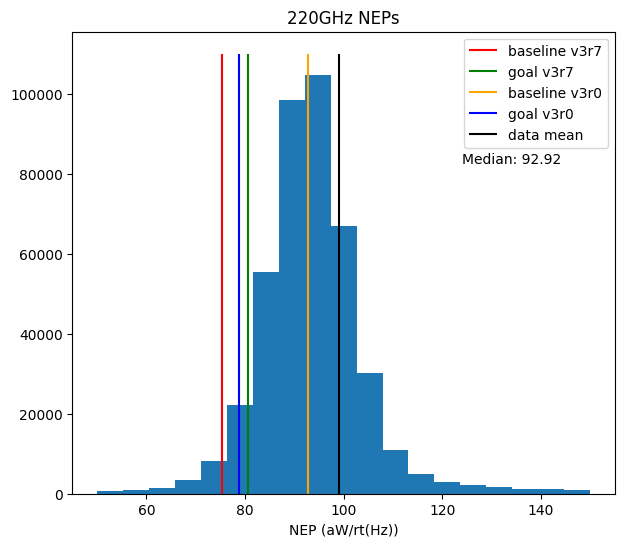

In [29]:
f, ax = plt.subplots(figsize=(7, 6))
flags = np.where((np.char.find(nep_labels, "220") != -1) & (neps>1e-6) & (1.1 < nep_df.pwv/np.sin(np.deg2rad(nep_df.el))) & (nep_df.pwv/np.sin(np.deg2rad(nep_df.el)) < 1.5))[0]

baseline_r0 = 92.86
baseline_r7 = 75.43

goal_r0 = 78.89
goal_r7 = 80.56

plt.hist(neps[flags]*1e6, bins = np.linspace(50,150, 20))
#plt.hist(neps_snork_090*1e6/baseline, bins = np.linspace(0,2, 20), label = "Snorkel Stare", density = True, alpha = 0.5)
ymax, ymin = ax.get_ylim()
xmax, xmin = ax.get_xlim()
plt.vlines(baseline_r7, ymin, ymax, label="baseline v3r7", color="red")
plt.vlines(goal_r7, ymin, ymax, label="goal v3r7", color="green")
plt.vlines(baseline_r0, ymin, ymax, label="baseline v3r0", color="orange")
plt.vlines(goal_r0, ymin, ymax, label="goal v3r0", color="blue")
plt.vlines(np.nanmean(neps[flags]*1e6), ymin, ymax, label="data mean", color="black")
plt.xlabel("NEP (aW/rt(Hz))")
plt.title("220GHz NEPs")
plt.legend()

plt.text(0.8*xmin, 0.75*ymin, "Median: {:.2f}".format(np.nanmedian(neps[flags]*1e6)))

f.savefig("./plts/neps/neps_220.pdf", dpi=600, bbox_inches='tight')
f.savefig("./plts/neps/neps_220.png", dpi=600, bbox_inches='tight')

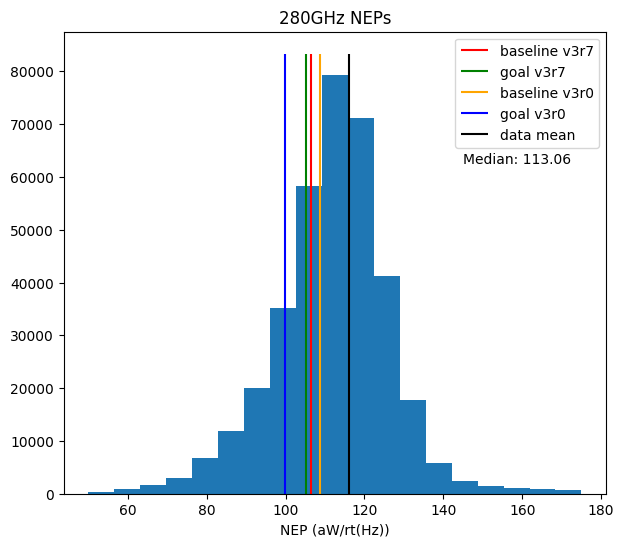

In [30]:
f, ax = plt.subplots(figsize=(7, 6))
flags = np.where((np.char.find(nep_labels, "280") != -1) & (neps>1e-6) & (1.1 < nep_df.pwv/np.sin(np.deg2rad(nep_df.el))) & (nep_df.pwv/np.sin(np.deg2rad(nep_df.el)) < 1.5))[0]

baseline_r0 = 108.63
baseline_r7 = 106.37

goal_r0 = 99.79
goal_r7 = 105.25

plt.hist(neps[flags]*1e6, bins = np.linspace(50,175, 20))
#plt.hist(neps_snork_090*1e6/baseline, bins = np.linspace(0,2, 20), label = "Snorkel Stare", density = True, alpha = 0.5)
ymax, ymin = ax.get_ylim()
xmax, xmin = ax.get_xlim()

plt.vlines(baseline_r7, ymin, ymax, label="baseline v3r7", color="red")
plt.vlines(goal_r7, ymin, ymax, label="goal v3r7", color="green")
plt.vlines(baseline_r0, ymin, ymax, label="baseline v3r0", color="orange")
plt.vlines(goal_r0, ymin, ymax, label="goal v3r0", color="blue")
plt.vlines(np.nanmean(neps[flags]*1e6), ymin, ymax, label="data mean", color="black")
plt.xlabel("NEP (aW/rt(Hz))")
plt.title("280GHz NEPs")
plt.legend()

plt.text(0.8*xmin, 0.75*ymin, "Median: {:.2f}".format(np.nanmedian(neps[flags]*1e6)))

f.savefig("./plts/neps/neps_280.pdf", dpi=600, bbox_inches='tight')
f.savefig("./plts/neps/neps_280.png", dpi=600, bbox_inches='tight')